# Module 08: Semi-Supervised, Self-Supervised, & Active Learning


## Module outline

* **Step 1: Semi-Supervised Learning**
  * The concept: combining a small labeled set with a larger unlabeled set.
  * Self-Training / Pseudo-Labeling: adding confident model predictions as temporary labels.
  * Label Propagation and Label Spreading: graph-based label movement through similar points.
* **Step 2: Self-Supervised Learning (Non-Neural)**
  * Designing pretext tasks for tabular, text, image, and time-series data.
  * Masked-value prediction, rotation prediction, next-step prediction, and contrastive similarity.
* **Step 3: Active Learning Pipelines**
  * The concept: asking a human to label the most useful unlabeled examples.
  * Query strategies: least confident sampling, margin sampling, entropy sampling, and query-by-committee.


## Module 8 Learning Goal

In normal supervised learning, every training row already has a target label. In real projects, labels are often the expensive part. For example, a doctor may need to label X-rays, a fraud analyst may need to review transactions, or a data team may need to tag thousands of text records.

This module teaches three ways to learn when labels are limited:

| Situation | Method | Main idea |
|---|---|---|
| Some labels exist, many labels are missing | Semi-supervised learning | Use unlabeled data carefully together with labeled data |
| No human labels are available for the first learning task | Self-supervised learning | Create a temporary task from the data itself |
| Human labels are possible but expensive | Active learning | Ask humans only for the most useful labels |

The examples use the `digits` image dataset from scikit-learn. It is small, built-in, and clear: each row is an 8×8 handwritten digit image, and the true label is the digit from 0 to 9. To simulate real life, we hide most labels and pretend they are unavailable.


Full dataset shape: (1797, 64)
Train rows: 1347 Test rows: 450
Each image shape: (8, 8)


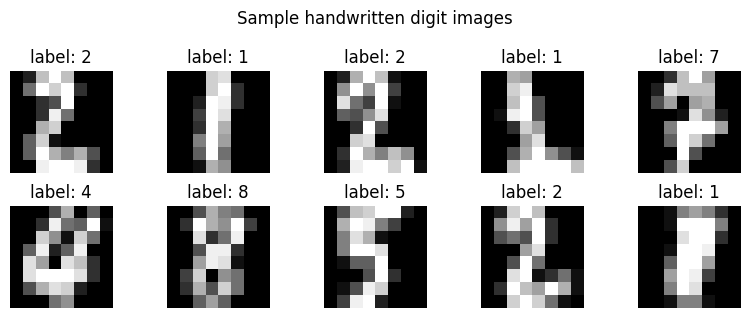

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = False
plt.rcParams['font.size'] = 10

rng = np.random.default_rng(42)
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images, test_size=0.25, random_state=42, stratify=y
)

print('Full dataset shape:', X.shape)
print('Train rows:', X_train.shape[0], 'Test rows:', X_test.shape[0])
print('Each image shape:', images[0].shape)

fig, axes = plt.subplots(2, 5, figsize=(8, 3.2))
for ax, image, label in zip(axes.ravel(), img_train[:10], y_train[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'label: {label}')
    ax.axis('off')
plt.suptitle('Sample handwritten digit images')
plt.tight_layout()
plt.show()


### Step 1 - Semi-Supervised Learning

**Definition:** Semi-supervised learning trains with two parts:

- a small labeled set: rows where the target is known
- a larger unlabeled set: rows where the input features are known but the target is missing

**Where it is used:** image labeling, medical records, fraud review, document classification, speech and audio tagging.

**Why it is useful:** unlabeled data still shows the shape of the problem. If similar examples form groups, the model can use those groups even when only a few rows have labels.

In scikit-learn, unlabeled rows are written as `-1` in the target array.

```text
Known label:     0, 1, 2, ...
Unknown label:  -1
```

The important warning is this: semi-supervised learning helps only when the unlabeled data has useful structure. If the model guesses wrongly and we trust those guesses too much, performance can get worse.


In [2]:
labels_per_class = 10
y_semi = np.full_like(y_train, fill_value=-1)

labeled_indices = []
for digit in np.unique(y_train):
    class_indices = np.where(y_train == digit)[0]
    chosen = rng.choice(class_indices, size=labels_per_class, replace=False)
    labeled_indices.extend(chosen)

y_semi[labeled_indices] = y_train[labeled_indices]

summary = pd.DataFrame({
    'Part': ['Labeled rows', 'Unlabeled rows', 'Test rows'],
    'Count': [(y_semi != -1).sum(), (y_semi == -1).sum(), len(y_test)]
})
display(summary)

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])
baseline.fit(X_train[y_semi != -1], y_train[y_semi != -1])
baseline_pred = baseline.predict(X_test)
print('Baseline accuracy using only the small labeled set:', round(accuracy_score(y_test, baseline_pred), 3))


,Part,Count
0,Labeled rows,100
1,Unlabeled rows,1247
2,Test rows,450


Baseline accuracy using only the small labeled set: 0.884


#### Self-Training / Pseudo-Labeling

**Definition:** Self-training means the model teaches itself by converting some confident predictions into temporary labels.

**Process:**

1. Train a normal supervised model on the rows that already have labels.
2. Predict probabilities for unlabeled rows.
3. Keep only predictions above a confidence threshold, such as 80% or 90%.
4. Add those rows back into the training set as pseudo-labeled rows.
5. Repeat until no more confident rows are added or a limit is reached.

**Why confidence threshold matters:** a low threshold adds more pseudo-labels but can add wrong labels. A high threshold is safer but may add fewer rows.

Pseudo-labels are not as trustworthy as human labels. They are useful only when the model is confident for the right reason.


In [3]:
base_estimator = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

self_training = SelfTrainingClassifier(
    estimator=base_estimator,
    threshold=0.80,
    max_iter=10,
    verbose=False
)
self_training.fit(X_train, y_semi)
self_pred = self_training.predict(X_test)

added = (self_training.transduction_ != -1).sum() - (y_semi != -1).sum()
print('Pseudo-labeled rows added by self-training:', added)
print('Self-training test accuracy:', round(accuracy_score(y_test, self_pred), 3))

comparison = pd.DataFrame({
    'Method': ['Only small labeled set', 'Self-training with pseudo-labels'],
    'Test Accuracy': [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, self_pred)]
})
display(comparison.round(3))


Pseudo-labeled rows added by self-training: 1165
Self-training test accuracy: 0.92


,Method,Test Accuracy
0,Only small labeled set,0.884
1,Self-training with pseudo-labels,0.920


#### Label Propagation and Label Spreading

These methods use a graph idea.

**Graph meaning:** each row is a point. Similar points are connected strongly. Dissimilar points are connected weakly. A known label can then move through strong connections.

```text
labeled digit 3  -> nearby similar images -> likely also digit 3
```

**Label Propagation:** spreads labels through the graph and tries to keep labeled points fixed.

**Label Spreading:** also spreads labels, but smooths the result with regularization. That smoothing can make it more stable when labels are noisy.

Key parameters:

| Parameter | Meaning |
|---|---|
| `kernel='rbf'` | similarity decreases smoothly with distance |
| `gamma` | controls how quickly similarity fades with distance |
| `alpha` in Label Spreading | controls smoothing strength |


In [4]:
subset_size = 600
subset_idx = rng.choice(np.arange(len(X_train)), size=subset_size, replace=False)
X_graph = X_train[subset_idx]
y_graph_true = y_train[subset_idx]
y_graph = np.full_like(y_graph_true, fill_value=-1)

for digit in np.unique(y_graph_true):
    class_indices = np.where(y_graph_true == digit)[0]
    chosen = rng.choice(class_indices, size=min(3, len(class_indices)), replace=False)
    y_graph[chosen] = y_graph_true[chosen]

label_prop = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LabelPropagation(kernel='rbf', gamma=0.01, max_iter=1000))
])
label_spread = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LabelSpreading(kernel='rbf', gamma=0.01, alpha=0.2, max_iter=1000))
])

label_prop.fit(X_graph, y_graph)
label_spread.fit(X_graph, y_graph)

prop_pred = label_prop.predict(X_test)
spread_pred = label_spread.predict(X_test)

results = pd.DataFrame({
    'Method': ['Label Propagation', 'Label Spreading'],
    'Known labels used': [(y_graph != -1).sum(), (y_graph != -1).sum()],
    'Unlabeled rows used': [(y_graph == -1).sum(), (y_graph == -1).sum()],
    'Test Accuracy': [accuracy_score(y_test, prop_pred), accuracy_score(y_test, spread_pred)]
})
display(results.round(3))


,Method,Known labels used,Unlabeled rows used,Test Accuracy
0,Label Propagation,30,570,0.100
1,Label Spreading,30,570,0.296


### Step 2 - Self-Supervised Learning Without Neural Networks

**Definition:** Self-supervised learning creates a temporary target from the data itself. The temporary target is called a **pretext task**.

It is not the final business task. It is a practice task that forces the model to learn useful structure.

| Data type | Pretext task | What the model may learn |
|---|---|---|
| Image | predict if the image was rotated | shape and orientation |
| Text | predict a missing word | word meaning and context |
| Tabular | predict a masked column | relationships between columns |
| Time series | predict the next step | trend and seasonality |
| Any data | contrastive similarity | which records should be close or far |

A good pretext task should require the model to understand something useful about the data. If the task is too easy or unrelated, the learned representation will not help later.


Rotation pretext task accuracy: 0.846
Labels for this task were created automatically: 0, 1, 2, 3 rotations.


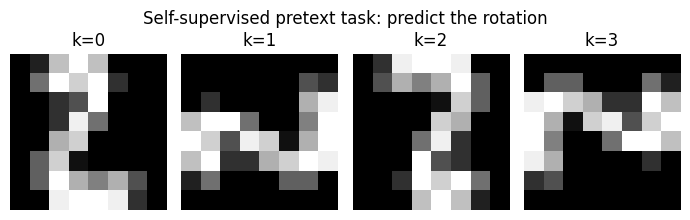

In [5]:
def rotate_flat_images(flat_images, labels):
    rotated = []
    for row, label in zip(flat_images, labels):
        image = row.reshape(8, 8)
        rotated.append(np.rot90(image, k=label).ravel())
    return np.array(rotated)

rotation_labels = rng.integers(0, 4, size=len(X_train))
X_rotated = rotate_flat_images(X_train, rotation_labels)

rot_X_train, rot_X_valid, rot_y_train, rot_y_valid = train_test_split(
    X_rotated, rotation_labels, test_size=0.25, random_state=42, stratify=rotation_labels
)

rotation_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])
rotation_model.fit(rot_X_train, rot_y_train)
rot_pred = rotation_model.predict(rot_X_valid)

print('Rotation pretext task accuracy:', round(accuracy_score(rot_y_valid, rot_pred), 3))
print('Labels for this task were created automatically: 0, 1, 2, 3 rotations.')

fig, axes = plt.subplots(1, 4, figsize=(7, 2.2))
example = X_train[0].reshape(8, 8)
for k, ax in enumerate(axes):
    ax.imshow(np.rot90(example, k=k), cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')
plt.suptitle('Self-supervised pretext task: predict the rotation')
plt.tight_layout()
plt.show()


#### Masked-Value Prediction and Contrastive Similarity

**Masked-value prediction:** hide part of the input and train the model to recover it.

Example for tabular data:

```text
Known: age, income, city, purchase_count
Hide:  income
Task:  predict income from the other fields
```

Example for text:

```text
The customer [MASK] the product.
Task: predict the missing word.
```

**Contrastive learning:** teach the model which pairs should be close and which pairs should be far.

```text
same digit with small noise      -> close pair
image of digit 2 and digit 8     -> far pair
```

The final output of self-supervised learning is often not the pretext prediction itself. The useful part is the representation learned before the final prediction layer.


In [6]:
from sklearn.metrics.pairwise import euclidean_distances

same_digit = np.where(y_train == y_train[0])[0][1]
different_digit = np.where(y_train != y_train[0])[0][0]

anchor = X_train[0:1]
positive = X_train[same_digit:same_digit+1]
negative = X_train[different_digit:different_digit+1]

same_distance = euclidean_distances(anchor, positive)[0, 0]
different_distance = euclidean_distances(anchor, negative)[0, 0]

contrastive_demo = pd.DataFrame({
    'Pair': ['Anchor with same digit', 'Anchor with different digit'],
    'Anchor_Label': [y_train[0], y_train[0]],
    'Other_Label': [y_train[same_digit], y_train[different_digit]],
    'Euclidean_Distance': [same_distance, different_distance]
})
display(contrastive_demo.round(2))
print('Contrastive learning tries to make useful similar pairs closer than different pairs in the learned representation.')


,Pair,Anchor_Label,Other_Label,Euclidean_Distance
0,Anchor with same digit,2,2,29.48
1,Anchor with different digit,2,1,45.18


Contrastive learning tries to make useful similar pairs closer than different pairs in the learned representation.


### Step 3 - Active Learning Pipelines

**Definition:** Active learning is a training loop where the model chooses which unlabeled rows should be labeled next by a human.

**Where it is used:** legal document review, fraud investigation, medical image labeling, customer-support ticket tagging, and any task where labels cost time or money.

**Why it is useful:** not all labels are equally helpful. If the model is already sure about a row, labeling it may teach little. If the model is confused, that row may teach more.

Basic pipeline:

```text
start with small labeled set
train model
score unlabeled examples
select most informative examples
human labels those examples
add them to labeled set
retrain
repeat
```


In [7]:
active_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])
active_model.fit(X_train[y_semi != -1], y_train[y_semi != -1])

unlabeled_idx = np.where(y_semi == -1)[0]
prob = active_model.predict_proba(X_train[unlabeled_idx])
classes = active_model.named_steps['model'].classes_

sorted_prob = np.sort(prob, axis=1)
top1 = sorted_prob[:, -1]
top2 = sorted_prob[:, -2]
least_confident = 1 - top1
margin = top1 - top2
entropy = -(prob * np.log2(prob + 1e-12)).sum(axis=1)

query_table = pd.DataFrame({
    'Train_Index': unlabeled_idx,
    'True_Label_hidden_for_demo': y_train[unlabeled_idx],
    'Predicted_Label': classes[np.argmax(prob, axis=1)],
    'Top_Probability': top1,
    'Least_Confident_Score': least_confident,
    'Margin_between_top_two': margin,
    'Entropy': entropy,
})

print('Least confident sampling: label rows where top probability is low.')
display(query_table.sort_values('Least_Confident_Score', ascending=False).head(8).round(3))
print('Margin sampling: label rows where top two probabilities are close.')
display(query_table.sort_values('Margin_between_top_two', ascending=True).head(8).round(3))
print('Entropy sampling: label rows where probability is spread across many classes.')
display(query_table.sort_values('Entropy', ascending=False).head(8).round(3))


Least confident sampling: label rows where top probability is low.


,Train_Index,True_Label_hidden_for_demo,Predicted_Label,Top_Probability,Least_Confident_Score,Margin_between_top_two,Entropy
1134,1224,8,1,0.244,0.756,0.017,2.907
490,525,9,3,0.262,0.738,0.012,2.377
161,171,2,2,0.282,0.718,0.001,2.225
106,110,9,9,0.291,0.709,0.032,2.274
1151,1243,8,8,0.295,0.705,0.114,2.772
469,503,8,5,0.299,0.701,0.082,2.710
822,885,7,7,0.301,0.699,0.051,2.477
716,769,8,8,0.309,0.691,0.043,2.563


Margin sampling: label rows where top two probabilities are close.


,Train_Index,True_Label_hidden_for_demo,Predicted_Label,Top_Probability,Least_Confident_Score,Margin_between_top_two,Entropy
161,171,2,2,0.282,0.718,0.001,2.225
54,55,8,3,0.370,0.630,0.004,2.068
147,156,2,2,0.489,0.511,0.006,1.206
490,525,9,3,0.262,0.738,0.012,2.377
1036,1122,3,7,0.371,0.629,0.012,2.075
715,768,7,4,0.377,0.623,0.013,2.092
127,135,2,2,0.440,0.560,0.014,1.623
1134,1224,8,1,0.244,0.756,0.017,2.907


Entropy sampling: label rows where probability is spread across many classes.


,Train_Index,True_Label_hidden_for_demo,Predicted_Label,Top_Probability,Least_Confident_Score,Margin_between_top_two,Entropy
1134,1224,8,1,0.244,0.756,0.017,2.907
1151,1243,8,8,0.295,0.705,0.114,2.772
1018,1103,2,2,0.334,0.666,0.158,2.746
746,800,8,8,0.406,0.594,0.276,2.726
469,503,8,5,0.299,0.701,0.082,2.710
35,36,2,7,0.342,0.658,0.159,2.692
330,352,8,9,0.341,0.659,0.109,2.628
929,1006,8,1,0.355,0.645,0.097,2.600


#### Query-by-Committee

**Definition:** Query-by-committee trains several different models and asks for labels where the models disagree.

The idea is simple:

```text
Model A says digit 3
Model B says digit 8
Model C says digit 3
```

This row is useful because the current model family is not sure. Human labeling can remove that confusion.

| Measure | Meaning |
|---|---|
| Vote entropy | high when committee votes are spread across classes |
| Disagreement count | high when many models differ from the majority |
| KL divergence | high when probability distributions disagree |


In [8]:
committee = [
    ('Logistic Regression', Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000, random_state=42))])),
    ('KNN', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))])),
    ('Random Forest', RandomForestClassifier(n_estimators=150, random_state=42))
]

votes = []
for name, model in committee:
    model.fit(X_train[y_semi != -1], y_train[y_semi != -1])
    votes.append(model.predict(X_train[unlabeled_idx]))

votes = np.vstack(votes).T
vote_entropy = []
for row_votes in votes:
    values, counts = np.unique(row_votes, return_counts=True)
    p = counts / counts.sum()
    vote_entropy.append(-(p * np.log2(p)).sum())

committee_df = pd.DataFrame({
    'Train_Index': unlabeled_idx,
    'True_Label_hidden_for_demo': y_train[unlabeled_idx],
    'Logistic_Vote': votes[:, 0],
    'KNN_Vote': votes[:, 1],
    'RandomForest_Vote': votes[:, 2],
    'Vote_Entropy': vote_entropy
})

print('Rows with the highest committee disagreement:')
display(committee_df.sort_values('Vote_Entropy', ascending=False).head(10).round(3))


Rows with the highest committee disagreement:


,Train_Index,True_Label_hidden_for_demo,Logistic_Vote,KNN_Vote,RandomForest_Vote,Vote_Entropy
1196,1290,3,5,8,1,1.585
35,36,2,7,8,6,1.585
1151,1243,8,8,3,6,1.585
1192,1286,4,4,0,7,1.585
51,52,9,8,7,5,1.585
1021,1107,9,0,9,3,1.585
1099,1187,5,5,3,9,1.585
65,67,9,9,1,4,1.585
1118,1208,1,3,1,7,1.585
1127,1217,9,9,1,4,1.585


## Module 8 Summary

- Semi-supervised learning uses a few labels plus many unlabeled rows.
- Self-training adds only confident pseudo-labels; wrong pseudo-labels can reinforce mistakes.
- Label Propagation and Label Spreading move labels through a similarity graph.
- Self-supervised learning creates a pretext task, such as rotation prediction or masked-value prediction.
- Active learning saves labeling effort by asking humans for high-value labels first.
- Least confidence, margin, entropy, and query-by-committee are different ways to decide what the model should ask next.
